## Directionality Analysis (OSAR)

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

filepath = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\2025 Complete raw values osar falling\OSAR_bothresponders_Full.xlsx"
df = pd.read_excel(filepath)
metric_cols = [c for c in df.columns if c not in ['MBON', 'responder']]
df['genotypeandresponder'] = df['MBON'] + '_' + df['responder']
negligible_threshold = 0.2

selected_metrics = ['PI_Hg_OSAR', 'Log2 Bout Speed ratio_Hg_OSAR',
                    'Light Attraction Index_Hg_OSAR', 'Bout Number Index_Hg_OSAR',
                    'Bout Duration ratio_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR']
if selected_metrics:
    metric_cols = [c for c in metric_cols if c in selected_metrics]

metric_display = {
    'PI_Hg_OSAR': 'PI',
    'Light Attraction Index_Hg_OSAR': 'LAI',
    # 'Log2 Speed ratio_Hg_OSAR': 'Log2 Speed',
    'Log2 Bout Speed ratio_Hg_OSAR': r'$\log_2$ Bout Speed',
    
    'Bout Number Index_Hg_OSAR': 'Bout #',
    'Bout Duration ratio_Hg_OSAR': 'Bout Duration',
    'Max Velocity ratio_Hg_OSAR': 'Max Velocity'

    # 'Speed ratio_Hg_OSAR': 'Speed Ratio',
    # 'Bout Speed ratio_Hg_OSAR': 'Bout Speed Ratio'
}

def classify(val):
    if abs(val) < negligible_threshold: return 0
    return 1 if val > 0 else -1

### Direction counts per responder

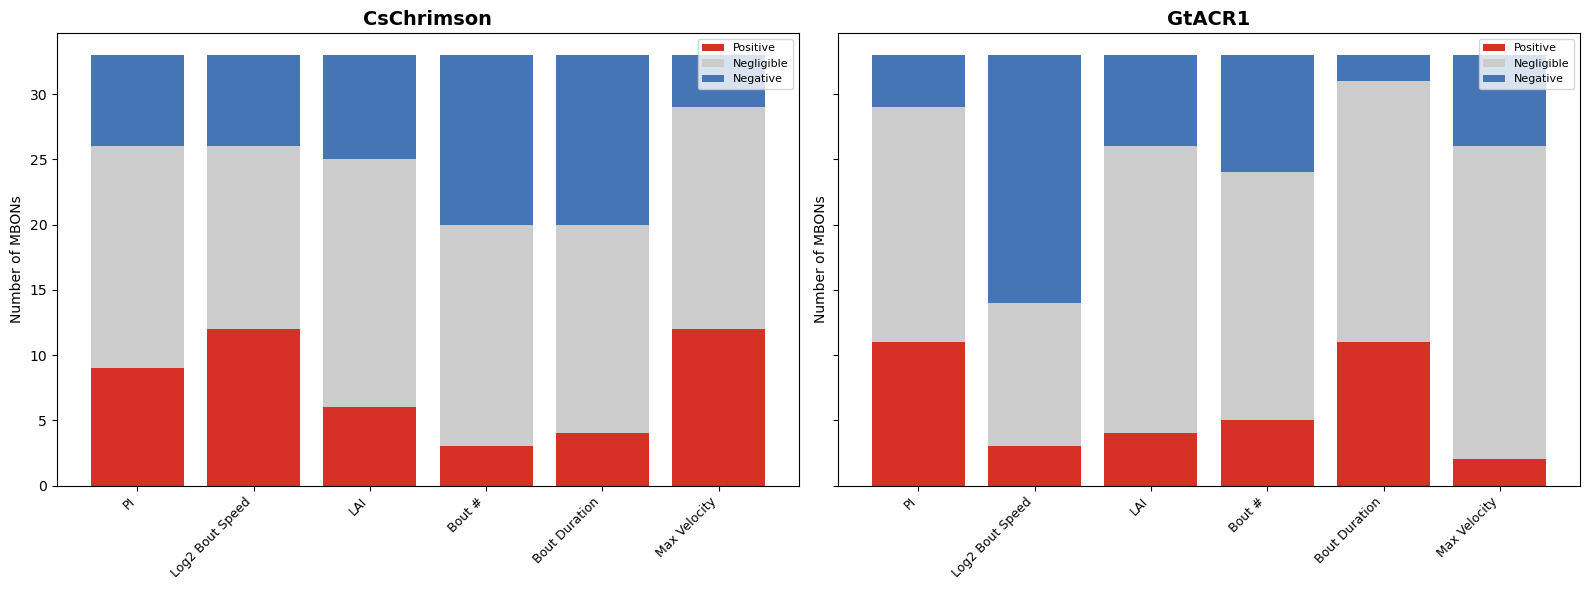

In [3]:
colors_dir = {1: '#d73027', 0: '#cccccc', -1: '#4575b4'}
labels_dir = {1: 'Positive', 0: 'Negligible', -1: 'Negative'}

responders = df['responder'].unique()
fig, axes = plt.subplots(1, len(responders), figsize=(8 * len(responders), 6), sharey=True)
if len(responders) == 1: axes = [axes]

for ax, resp in zip(axes, responders):
    subset = df[df['responder'] == resp]
    counts = {d: [] for d in [1, 0, -1]}
    display_names = []
    for metric in metric_cols:
        dirs = subset[metric].apply(classify)
        for d in [1, 0, -1]: counts[d].append((dirs == d).sum())
        display_names.append(metric_display.get(metric, metric))

    x = range(len(metric_cols))
    bottom = np.zeros(len(metric_cols))
    for d in [1, 0, -1]:
        ax.bar(x, counts[d], bottom=bottom, color=colors_dir[d], label=labels_dir[d])
        bottom += np.array(counts[d])

    ax.set_xticks(x)
    ax.set_xticklabels(display_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of MBONs')
    resp_label = 'CsChrimson' if resp == 'Chrimson2' else 'GtACR1'
    ax.set_title(resp_label, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Direction heatmap per MBON x metric

In [65]:
def find_number(csvdf, lookup, col):
    vals = []
    for _, row in csvdf.iterrows():
        if lookup in [x.strip() for x in row['MBON names'].split(',')]:
            vals.append(row[col])
    return ', '.join(list(set(vals)))
def create_label(mbon, lobeloc):
    info = lobeloc[lobeloc['MBON'] == mbon]
    if len(info) > 0:
        parts = [str(info['MBON_number'].values[0]), mbon]
        return '\n'.join([p for p in parts if p and p != 'nan']) or mbon
    return mbon

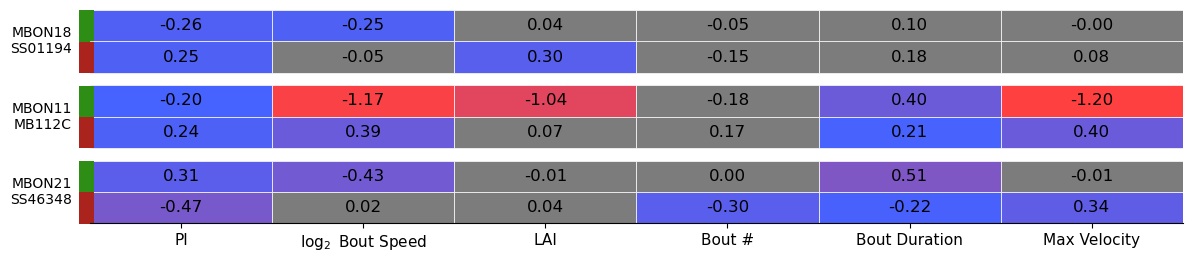

In [64]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Rectangle

selected_mbon = ['SS81521', 'SS67662', 'SS77450', 'SS75200', 'SS77442']
selected_mbon = ['SS01194', "MB112C", "SS46348"]
responder_colors = {'ACR': "#2D8D15", 'Chrimson2': "#aa231c"}
responder_order = ['ACR', 'Chrimson2']
GAP_SIZE = 0.4

mbon_csv_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
csvfile = pd.read_csv(mbon_csv_path).astype('string')

lobelocation = pd.DataFrame()
for m in selected_mbon:
    row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
           'MBON_number': find_number(csvfile, m, "MBON number").strip()}
    lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
lobelocation = lobelocation.reset_index(drop=True)

sub = df[df['MBON'].isin(selected_mbon)].copy()
sub['responder_rank'] = sub['responder'].map({r: i for i, r in enumerate(responder_order)})
sub['mbon_rank'] = sub['MBON'].map({m: i for i, m in enumerate(selected_mbon)})
sub = sub.sort_values(['mbon_rank', 'responder_rank'])
subset = sub.set_index('genotypeandresponder')[metric_cols]

threshold = 0.2
abs_vals = subset.abs()
below = abs_vals < threshold

purple_cmap = LinearSegmentedColormap.from_list('purple_mag', ["#4662ff", "#ff4040"])
gray_cmap = ListedColormap(["#7c7c7c"])

n_mbons = len(selected_mbon)
n_resp = len(responder_order)
n_cols = len(metric_cols)
total_height = n_mbons * n_resp + (n_mbons - 1) * GAP_SIZE

fig, ax = plt.subplots(figsize=(12, total_height * 0.4))

row_idx = 0
for i, mbon in enumerate(selected_mbon):
    y_top = i * (n_resp + GAP_SIZE)

    for j, resp in enumerate(responder_order):
        data_row = row_idx
        y = y_top + j

        for c in range(n_cols):
            val = subset.iloc[data_row, c]
            aval = abs(val)
            if aval < threshold:
                color = "#7c7c7c"
            else:
                normed = (aval - threshold) / (abs_vals.max().max() - threshold)
                color = purple_cmap(normed)
            rect = Rectangle((c, y), 1, 1, facecolor=color, edgecolor='white', linewidth=0.5)
            ax.add_patch(rect)
            ax.text(c + 0.5, y + 0.5, f"{val:.2f}", ha='center', va='center', fontsize=12)

        resp_rect = Rectangle((-0.06, y + 0.01), 0.08, 1.0,
                               facecolor=responder_colors[resp], edgecolor='none', clip_on=False)
        ax.add_patch(resp_rect)

        row_idx += 1

    mid_y = y_top + 1.0
    label = create_label(mbon, lobelocation)
    ax.text(-0.1, mid_y, label, ha='right', va='center', fontsize=10)

ax.set_xlim(0, n_cols)
ax.set_ylim(total_height, 0)

xticks_labels = [metric_display.get(col, col) for col in subset.columns]
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(xticks_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.set_yticks([])
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

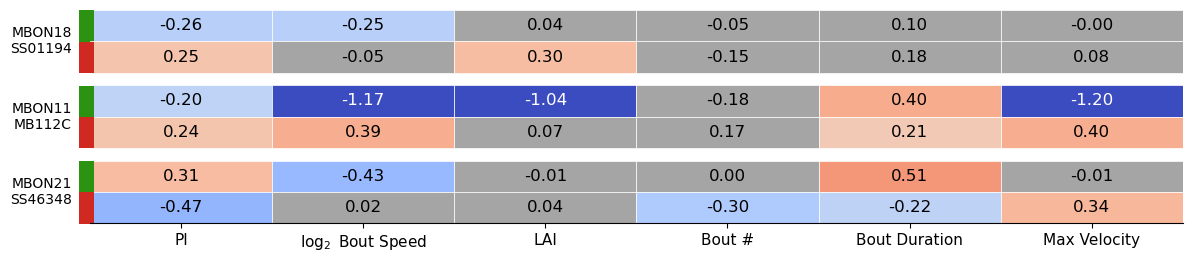

In [69]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, to_rgba
from matplotlib.patches import Rectangle

#selected_mbon = ['SS81521', 'SS67662', 'SS77450', 'SS75200', 'SS77442']
selected_mbon = ['SS01194', "MB112C", "SS46348"]
responder_colors = {'ACR': "#2C9212", 'Chrimson2': "#cf2921"}
responder_order = ['ACR', 'Chrimson2']
GAP_SIZE = 0.4

USE_COOLWARM = True
VMIN = -1.0
VMAX = 1.0

if USE_COOLWARM:
    active_cmap = plt.cm.coolwarm
else:
    active_cmap = LinearSegmentedColormap.from_list('div', ["#4580fd", "#ffffff", "#ff2020"])

mbon_csv_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
csvfile = pd.read_csv(mbon_csv_path).astype('string')

lobelocation = pd.DataFrame()
for m in selected_mbon:
    row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
           'MBON_number': find_number(csvfile, m, "MBON number").strip()}
    lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
lobelocation = lobelocation.reset_index(drop=True)

sub = df[df['MBON'].isin(selected_mbon)].copy()
sub['responder_rank'] = sub['responder'].map({r: i for i, r in enumerate(responder_order)})
sub['mbon_rank'] = sub['MBON'].map({m: i for i, m in enumerate(selected_mbon)})
sub = sub.sort_values(['mbon_rank', 'responder_rank'])
subset = sub.set_index('genotypeandresponder')[metric_cols]

threshold = 0.2
abs_vals = subset.abs()

n_mbons = len(selected_mbon)
n_resp = len(responder_order)
n_cols = len(metric_cols)
total_height = n_mbons * n_resp + (n_mbons - 1) * GAP_SIZE

fig, ax = plt.subplots(figsize=(12, total_height * 0.4))

row_idx = 0
for i, mbon in enumerate(selected_mbon):
    y_top = i * (n_resp + GAP_SIZE)

    for j, resp in enumerate(responder_order):
        data_row = row_idx
        y = y_top + j

        for c in range(n_cols):
            val = subset.iloc[data_row, c]
            aval = abs(val)
            if aval < threshold:
                color = "#a5a5a5"
            else:
                normed = np.clip((val - VMIN) / (VMAX - VMIN), 0, 1)
                color = active_cmap(normed)
            rgba = to_rgba(color)
            lum = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'white' if lum < 0.5 else 'black'
            rect = Rectangle((c, y), 1, 1, facecolor=color, edgecolor='white', linewidth=0.5)
            ax.add_patch(rect)
            ax.text(c + 0.5, y + 0.5, f"{val:.2f}", ha='center', va='center', fontsize=12, color=txt_color)

        resp_rect = Rectangle((-0.06, y + 0.01), 0.08, 1.0,
                               facecolor=responder_colors[resp], edgecolor='none', clip_on=False)
        ax.add_patch(resp_rect)

        row_idx += 1

    mid_y = y_top + 1.0
    label = create_label(mbon, lobelocation)
    ax.text(-0.1, mid_y, label, ha='right', va='center', fontsize=10)

ax.set_xlim(0, n_cols)
ax.set_ylim(total_height, 0)

xticks_labels = [metric_display.get(col, col) for col in subset.columns]
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(xticks_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.set_yticks([])
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Agreement across responders

MBONs in both: 33
  PI                    same=5  opposite=4  negligible=24
  Log2 Bout Speed       same=5  opposite=6  negligible=22
  LAI                   same=1  opposite=2  negligible=30
  Bout #                same=7  opposite=1  negligible=25
  Bout Duration         same=3  opposite=5  negligible=25
  Max Velocity          same=1  opposite=5  negligible=27


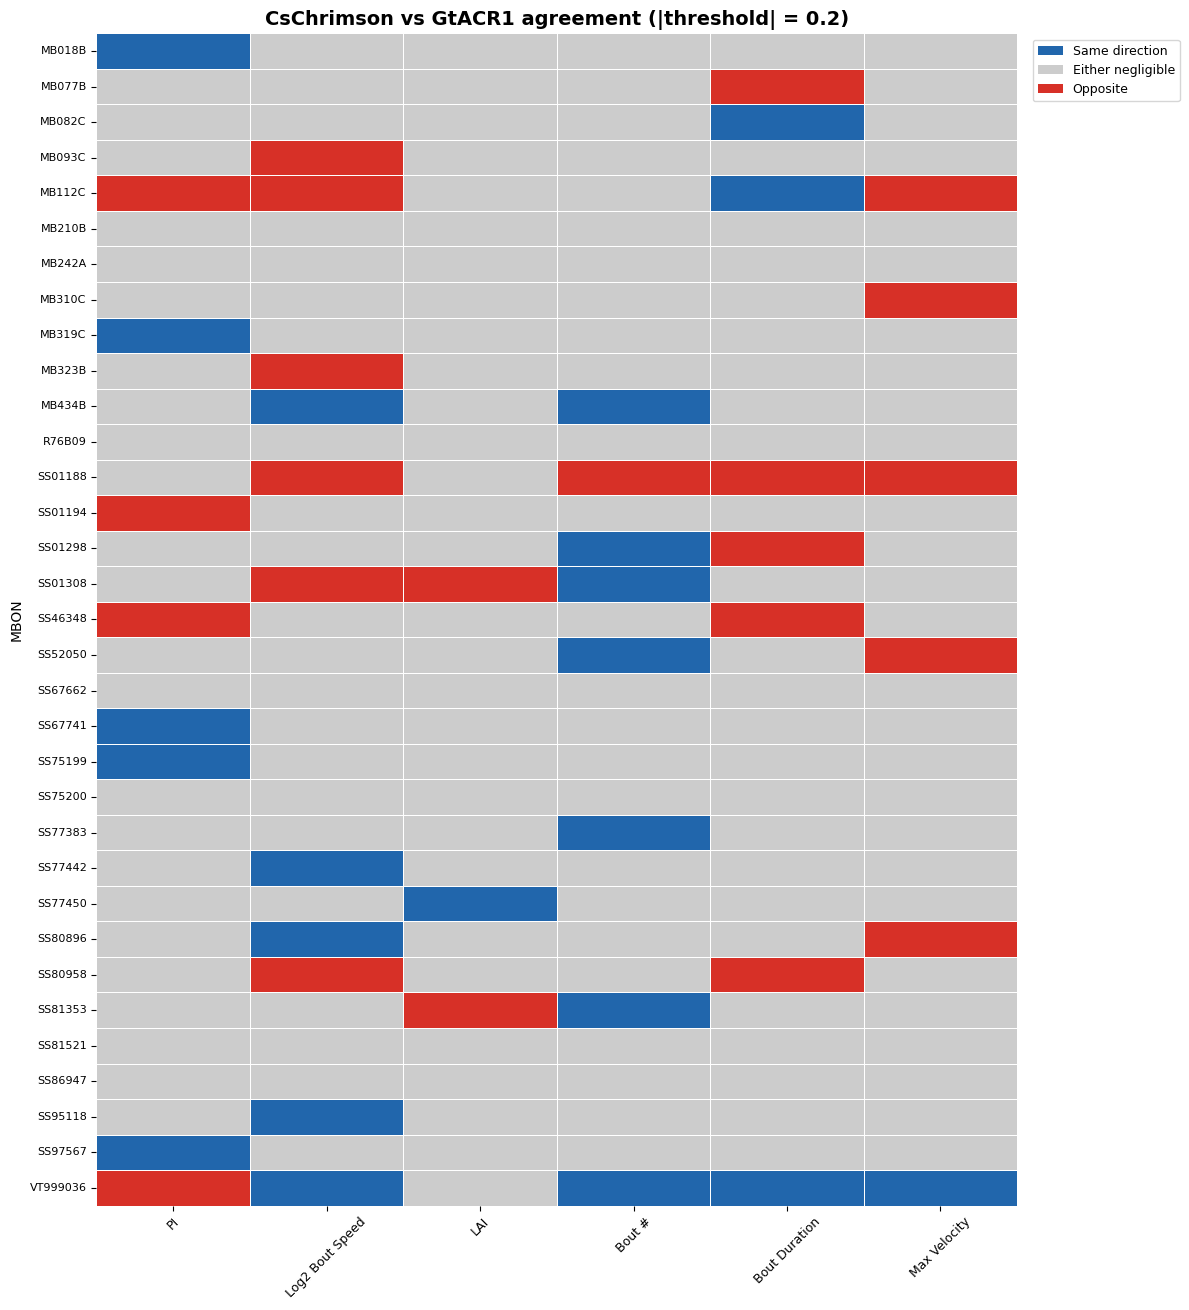

In [3]:
r1, r2 = responders[0], responders[1]
df1 = df[df['responder'] == r1].set_index('MBON')[metric_cols]
df2 = df[df['responder'] == r2].set_index('MBON')[metric_cols]
common = df1.index.intersection(df2.index)

dir1 = df1.loc[common].map(classify)
dir2 = df2.loc[common].map(classify)

agree_map = pd.DataFrame(0, index=common, columns=metric_cols)
agree_map[(dir1 == dir2) & (dir1 != 0)] = 1
agree_map[((dir1 == 1) & (dir2 == -1)) | ((dir1 == -1) & (dir2 == 1))] = -1
agree_map.columns = [metric_display.get(c, c) for c in agree_map.columns]

r1_label = 'CsChrimson' if r1 == 'Chrimson2' else 'GtACR1'
r2_label = 'CsChrimson' if r2 == 'Chrimson2' else 'GtACR1'

print(f"MBONs in both: {len(common)}")
for metric in agree_map.columns:
    same = (agree_map[metric] == 1).sum()
    opp = (agree_map[metric] == -1).sum()
    negl = (agree_map[metric] == 0).sum()
    print(f"  {metric:20s}  same={same}  opposite={opp}  negligible={negl}")

fig, ax = plt.subplots(figsize=(12, len(common) * 0.4))
cmap_agree = plt.cm.colors.ListedColormap(['#d73027', '#cccccc', '#2166ac'])
sns.heatmap(agree_map, cmap=cmap_agree, center=0, vmin=-1.5, vmax=1.5,
            linewidths=0.5, linecolor='white', cbar=False, ax=ax)
ax.legend(handles=[Patch(facecolor='#2166ac', label='Same direction'),
                   Patch(facecolor='#cccccc', label='Either negligible'),
                   Patch(facecolor='#d73027', label='Opposite')],
          loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.set_title(f'{r1_label} vs {r2_label} agreement (|threshold| = {negligible_threshold})', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=9, rotation=45)
plt.tight_layout()
plt.show()

### MBONs grouped by agreement level

In [11]:
all_dir = df.set_index('genotypeandresponder')[metric_cols].map(classify)
display_cols = [metric_display.get(c, c) for c in metric_cols]

pattern_groups = all_dir.groupby(list(metric_cols)).groups
pattern_groups = {k: list(v) for k, v in pattern_groups.items() if len(v) > 1}
pattern_groups = dict(sorted(pattern_groups.items(), key=lambda x: -len(x[1])))

for pattern, members in pattern_groups.items():
    dir_labels = {1: '+', 0: '~0', -1: '-'}
    pattern_str = ', '.join(f"{col}={dir_labels[d]}" for col, d in zip(display_cols, pattern))
    print(f"Group ({len(members)} members): [{pattern_str}]")
    for m in members:
        print(f"  {m}")
    print()

Group (5 members): [PI=~0, Log2 Bout Speed=-, LAI=~0, Bout #=~0, Bout Duration=~0, Max Velocity=~0]
  SS77442_Chrimson2
  MB323B_ACR
  MB242A_ACR
  MB093C_ACR
  SS86947_ACR

Group (5 members): [PI=~0, Log2 Bout Speed=~0, LAI=~0, Bout #=~0, Bout Duration=~0, Max Velocity=~0]
  MB242A_Chrimson2
  SS86947_Chrimson2
  SS81521_ACR
  SS67662_ACR
  R76B09_ACR

Group (3 members): [PI=~0, Log2 Bout Speed=+, LAI=~0, Bout #=-, Bout Duration=-, Max Velocity=~0]
  SS77383_Chrimson2
  SS80958_Chrimson2
  SS01298_Chrimson2

Group (2 members): [PI=~0, Log2 Bout Speed=~0, LAI=~0, Bout #=~0, Bout Duration=~0, Max Velocity=+]
  MB210B_Chrimson2
  SS75200_ACR

Group (2 members): [PI=+, Log2 Bout Speed=~0, LAI=+, Bout #=~0, Bout Duration=~0, Max Velocity=~0]
  SS01194_Chrimson2
  SS67741_Chrimson2

Group (2 members): [PI=+, Log2 Bout Speed=+, LAI=~0, Bout #=-, Bout Duration=-, Max Velocity=-]
  SS81521_Chrimson2
  VT999036_ACR

